#### Determinazione Entalpia di Vaporizzazione <strong>EtOH</strong>


<div style="float: right; width: 180px; margin-left: 20px;">

<figure style="margin: 0 0 15px 0;">
  <img src="imm.png" style="width: 100%;">
  <figcaption style="font-size: 0.85em;">
    <strong>Figura 1</strong> — Schema dell’apparato di Tobey
  </figcaption>
</figure>


<table style="font-size: 0.85em; margin-left: 20px; text-align: center;">
    </p>
    <th>misura</th>
    <th>p/mmHg</th>
    <th>t/°C</th>
  </tr>
  <tr><td>0</td><td>446</td><td>56.3</td></tr>
  <tr><td>1</td><td>410</td><td>58.7</td></tr>
  <tr><td>2</td><td>378</td><td>60.7</td></tr>
  <tr><td>3</td><td>346</td><td>62.7</td></tr>
  <tr><td>4</td><td>312</td><td>64.5</td></tr>
  <tr><td>5</td><td>283</td><td>66.0</td></tr>
  <tr><td>6</td><td>251</td><td>67.6</td></tr>
  <tr><td>7</td><td>235</td><td>68.2</td></tr>
  <tr><td>8</td><td>218</td><td>69.0</td></tr>
  <tr><td>9</td><td>192</td><td>70.1</td></tr>
  <tr><td>10</td><td>166</td><td>71.1</td></tr>
  <tr><td>11</td><td>140</td><td>72.2</td></tr>
  <tr><td>12</td><td>114</td><td>73.2</td></tr>
  <tr><td>13</td><td>80</td><td>74.4</td></tr>
  <tr><td>14</td><td>60</td><td>75.1</td></tr>
  <tr><td>15</td><td>30</td><td>76.0</td></tr>
  <tr><td>16</td><td>26</td><td>76.3</td></tr>
  <tr>
  <td>\(P_{\text{ext}}\)</td>
  <td>737</td>
  <td><strong>STD</strong></td>
</tr>
    <figcaption style="font-size: 0.85em;">
    <strong>Tabella 1 </strong> — Dati Sperimentali 
  </figcaption>
</table>
</div>

<div style="font-size: 0.8em;">
    
###### Descrizione
Si è suato l'apparato di Tobey esemplificato in <strong>Figura 1.1</strong>strong, per ricavare l'entalpia di vaporizzazione di etanolo. Dopo aver fatto scorrere il refrigerante nel dito freddo si è fatto il vuoto fino al valore di 446 mmHg, di pressione interna, tenendo conto che la pressione esterna al sistema fosse 737 mmHg.<br>
<br>
Si è aumentata la pressione di 30 mmHg facendo sfiatare il vuoto, dopo il raggiungimento dell'equilibrio si sono recuperati i dati di pressione e temperatura. <br>
<br>
Si è iterato fino a che la pressione interna non uguagliasse4 la pressione esterna del laboratorio. <br>



Dai dati sperimentali riportati in tabella bisogna:


1) Riportare in grafico il logaritmo della pressione in funzione dell'inverso della temperatura con le relative barre di errore. <br> 
2) Con il metodo dei minimi quadrati determinare il $\Delta{H}$  di <strong>EtOH</strong> e l'errore associato.
3) Ricavare il $\Delta{S}$ di <strong>EtOH</strong> e l'errore associato. Verificare la regola di Tourton.
</div>
<div style="font-size: 0.8em;">
__________________________________________________________________________________________________________________________________________________<br>
<strong>
<span style="color: red;">
[HINT] <br>
</span>
- operare la differenza tra pressione esterna e interna per ogni dato di pressione;<br>
- convertire la temperatura in Kelvin.    
</strong>
__________________________________________________________________________________________________________________________________________________<br>
</div>
<br>

<div style="font-size: 1.0em; margin-left: 20px; text-align: right;">
    ln(p) = &Delta;H<sub>vap,m</sub>$\frac{1}{T}$ + c
      </div>
      
###### Quesito 1
Segue il grafico costruito grazie alle librerie python riportate in fondo al seguente file.<br>
La misura è stata effettuata con l'obiettivo di ricavare l'entalpia di vaporizzazione per l'etalono tramite l'equazione di Tourton.<br>
Dopo aver inserito i dati si è definità una classe caratterizzata da due funzionali:
- *f_manip(Inner)*, che trasforma i punti sperimentali nella forma conforme all'equazione di Tourton prendendo l'intervallo di ogni valore in ragione della sensibilità di termometro e manometro; <br>
- *graph(Inner)*, che grafica i risultati trasformati con le relative barre di errore.<br>
<br>
Seguono i due diagrammi in <strong>Figura 2</strong>:
<figure style="margin: 0 0 15px 0;">
  <img src="grafico_00.png" style="width: 38%;">
    <img src="grafico_01.png" style="width:38%">
  <figcaption style="font-size: 0.85em;">
    <strong>Figura 2</strong>
  </figcaption>
</figure>
</div>

<br>

###### Quesito 2
<div style="font-size: 1.0em;margin-left:20px;text-aligned:left;">
Si è determinato il  &Delta;H<sub>vap,m</sub>, sfruttando il metodo dei minimi quadrati in forma matriciale secondo il sueguenter algoritmo:
    - Si e creato il vettore per i valori delle variabili ln(p) e di 1/T;
    - Si è costruita la jacobiana per il problema;
<div style="font-size: 1.0em; margin-left: 20px; text-align: cenetert;">
  <strong>
     $y_{i} = ln(p_{i})$
      </strong> <br>
     $y^{m} = sum{ln(p_{i})}$
    <strong>
        $x_{i} = T_{i} $
        </strong>
</div>
</div>


In [103]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter

class Data:
    def __init__(self, p_exp, p_comp):
        self.p_exp = p_exp
        self.p_comp = p_comp

    def tests(self):
        if len(self.p_exp['press']) != len(self.p_exp['temp']):
            print("Errore: pressione e temperatura hanno lunghezze diverse")
            return

        print("!! TEST data-ending !!")
        print(
            f"risultato positivo,\n"
            f"sono stati immessi {len(self.p_exp['press'])} valori di pressione\n"
            f"sono stati immessi {len(self.p_exp['temp'])} valori di temperatura"
        )

        print("Dati inseriti:")
        print("[pressione, temperatura]")
        for press, temp in zip(self.p_exp['press'], self.p_exp['temp']):
            print(f"[   {press}    {temp}   ]")

    def f_manip(self, Inner0):
        out0 = np.zeros(len(Inner0))
        out1 = [np.zeros(len(Inner0)), np.zeros(len(Inner0))]

        if Inner0 == self.p_exp['press']:
            for i in range(len(Inner0)):
                p_ext = self.p_exp['p_ext']
                sens_P = self.p_exp['sens_P']

                out0[i] = np.log(p_ext - Inner0[i])

                valore_basso = np.log(p_ext - Inner0[i] - sens_P)
                valore_alto = np.log(p_ext - Inner0[i] + sens_P)

                out1[0][i] = abs(out0[i] - valore_basso)
                out1[1][i] = abs(valore_alto - out0[i])

            self.p_comp['lnp'] = out0
            self.p_comp['lnp_err'] = out1

        elif Inner0 == self.p_exp['temp']:
            for i in range(len(Inner0)):
                sens_t = self.p_exp['sens_t']

                T = 273.15 + Inner0[i]

                out0[i] = 1 / T
                np.set_printoptions(formatter={'float_kind': lambda x: f"{x:.3e}"})

                valore_basso = 1 / (T + sens_t)
                valore_alto = 1 / (T - sens_t)

                out1[0][i] = abs(out0[i] - valore_basso)
                out1[1][i] = abs(valore_alto - out0[i])

            self.p_comp['1/T'] = out0
            self.p_comp['1/T_err'] = out1

        else:
            raise ValueError("Inner0 deve essere p_exp['press'] oppure p_exp['temp']")

        return out0, out1

    def graph1(self):
        x = self.p_comp['1/T']
        y = self.p_comp['lnp']

        xerr = self.p_comp['1/T_err']
        
        plt.figure()
        plt.title('ln(p) in funzione di 1/T, [barre di errore su 1/T)]')
        plt.xlabel('(1/T)/K^-1')
        plt.ylabel('ln(p)')

        plt.errorbar(
            x,
            y,
            xerr=xerr,
            fmt='-',
            capsize=10,
            color='black',
            label= xerr
        )
        plt.scatter(x, y, color="blue", label="Punti sperimentali")
        
        plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1e'))
        plt.savefig("grafico_00.png", dpi=300, bbox_inches="tight")
        plt.show()

    def graph2(self):
        x = self.p_comp['1/T']
        y = self.p_comp['lnp']

        yerr = self.p_comp['lnp_err']

        plt.figure()
        plt.title('ln(p) in funzione di 1/T, [barre di errore su ln(p)]')
        plt.xlabel('(1/T)/K^-1')
        plt.ylabel('ln(p)')

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            fmt='-',
            capsize=10,
            color='black',
            label= r'aevwverfv {yerr}'
        )
        plt.scatter(x, y, color="red", label="Punti sperimentali")
        
        plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1e'))
        plt.savefig("grafico_01.png", dpi=300, bbox_inches="tight")
        plt.show()



        

                


In [104]:

p_exp = {
    'press': [446,410,378,346,312,283,251,235,218,192,166,140,114,80,60,34,26],
    'temp': [56.3,58.7,60.7,62.6,64.5,66.0,67.6,68.2,69.0,70.1,71.1,72.2,73.2,74.4,75.1,76.0,76.3],
    "p_ext": 737,
    "sens_P": 1,
    "sens_t": 0.01
}

p_comp = {
    'lnp': np.zeros(len(p_exp['press'])),
    '1/T': np.zeros(len(p_exp['temp'])),
}

U = Data(p_exp, p_comp)

U.tests()


!! TEST data-ending !!
risultato positivo,
sono stati immessi 17 valori di pressione
sono stati immessi 17 valori di temperatura
Dati inseriti:
[pressione, temperatura]
[   446    56.3   ]
[   410    58.7   ]
[   378    60.7   ]
[   346    62.6   ]
[   312    64.5   ]
[   283    66.0   ]
[   251    67.6   ]
[   235    68.2   ]
[   218    69.0   ]
[   192    70.1   ]
[   166    71.1   ]
[   140    72.2   ]
[   114    73.2   ]
[   80    74.4   ]
[   60    75.1   ]
[   34    76.0   ]
[   26    76.3   ]


[5.673e+00 5.790e+00 5.883e+00 5.969e+00 6.052e+00 6.118e+00 6.186e+00
 6.219e+00 6.252e+00 6.301e+00 6.347e+00 6.392e+00 6.435e+00 6.488e+00
 6.518e+00 6.555e+00 6.567e+00]
[array([3.442e-03, 3.063e-03, 2.789e-03, 2.561e-03, 2.356e-03, 2.205e-03,
       2.060e-03, 1.994e-03, 1.929e-03, 1.837e-03, 1.753e-03, 1.676e-03,
       1.606e-03, 1.523e-03, 1.478e-03, 1.423e-03, 1.407e-03]), array([3.431e-03, 3.053e-03, 2.782e-03, 2.554e-03, 2.350e-03, 2.200e-03,
       2.055e-03, 1.990e-03, 1.925e-03, 1.833e-03, 1.750e-03, 1.674e-03,
       1.604e-03, 1.521e-03, 1.476e-03, 1.421e-03, 1.405e-03])]
[3.035e-03 3.013e-03 2.995e-03 2.978e-03 2.962e-03 2.949e-03 2.935e-03
 2.930e-03 2.923e-03 2.913e-03 2.905e-03 2.896e-03 2.887e-03 2.877e-03
 2.872e-03 2.864e-03 2.862e-03]
[array([9.213e-08, 9.080e-08, 8.972e-08, 8.871e-08, 8.771e-08, 8.694e-08,
       8.612e-08, 8.582e-08, 8.542e-08, 8.487e-08, 8.438e-08, 8.384e-08,
       8.336e-08, 8.279e-08, 8.245e-08, 8.203e-08, 8.189e-08]), array([9.214e-08, 9.

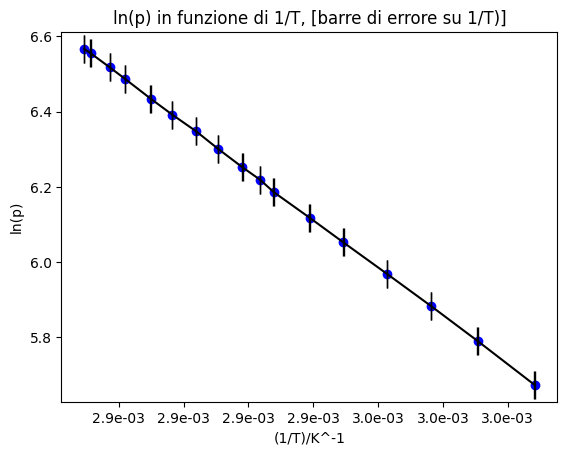

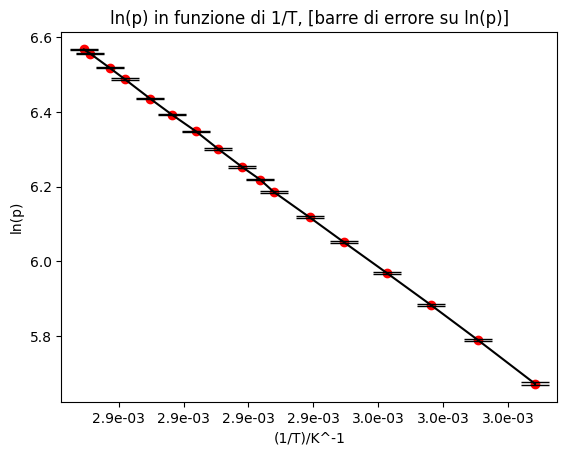

In [105]:

lnp_calc, lnp_err = U.f_manip(p_exp['press'])
under_T_calc, under_T_err = U.f_manip(p_exp['temp'])

print(lnp_calc)
print(lnp_err)

print(under_T_calc)
print(under_T_err)

U.graph1()
U.graph2()
